# 딥러닝-전이학습 ResNet 모델

CIFAR-10 데이터셋을 사용해 ResNet34 기반 전이학습 모델을 만들어봅니다.

이번 노트북의 목표는 다음과 같습니다.

- CIFAR-10 데이터셋의 구조를 확인합니다.
- 학습용 데이터는 `DataLoader`로 준비합니다.
- 검증/테스트 데이터는 텐서로 변환해 평가에 사용합니다.
- ResNet의 핵심 구조인 residual connection을 코드로 확인합니다.
- ImageNet으로 사전 학습된 ResNet34 모델을 불러옵니다.
- ResNet34의 마지막 `fc` layer를 CIFAR-10의 10개 클래스에 맞게 교체합니다.
- 학습 곡선, confusion matrix, classification report로 성능을 확인합니다.

![](https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png)

## 1. 환경 준비

필요한 라이브러리와 반복해서 사용할 함수를 먼저 준비합니다.

### 1.1 라이브러리 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
import torch.nn.functional as F

from torchvision import datasets, transforms
from torchvision.models import resnet34, ResNet34_Weights

### 1.2 필요 함수 생성

학습, 검증, 학습 곡선 시각화, 평가 리포트 출력을 위한 함수를 정의합니다.

- `train` 함수: 한 epoch 동안 미니배치 학습을 수행하고 평균 train loss를 반환합니다.

In [ ]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()
    total_loss = 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)

- `evaluate` 함수: validation 또는 test 데이터 전체에 대해 loss와 예측값을 반환합니다.

In [ ]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device, batch_size=128):
    """검증/테스트 데이터에 대한 평균 loss와 모델 출력값을 반환합니다."""
    model.eval()

    eval_dataset = TensorDataset(x_val_tensor, y_val_tensor)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0
    pred_list = []

    with torch.no_grad():
        for x, y in eval_loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * x.size(0)
            pred_list.append(pred.cpu())

    eval_loss = total_loss / len(eval_dataset)
    pred = torch.cat(pred_list, dim=0)

    return eval_loss, pred

- `dl_learning_curve` 함수: train loss, validation loss, validation accuracy를 한 그래프에 표시합니다.

In [ ]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.plot(epochs, val_acc_list, label="val_acc", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

- `predict_class`, `evaluate_report` 함수: logits를 클래스 번호로 바꾸고 평가 결과를 출력합니다.

In [ ]:
def predict_class(pred):
    """모델 출력(logits)을 최종 클래스 번호로 변환합니다."""
    pred_prob = nn.functional.softmax(pred, dim=1)
    return np.argmax(pred_prob.cpu().numpy(), axis=1)


def evaluate_report(x_test, y_test, model, loss_fn, device, classes):
    """테스트 데이터의 confusion matrix와 classification report를 출력합니다."""
    _, pred = evaluate(x_test, y_test, model, loss_fn, device)
    pred = predict_class(pred)

    cm = confusion_matrix(y_test.numpy(), pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues")
    plt.xticks(rotation=90)
    plt.show()

    print("=" * 80)
    print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
    print("-" * 80)
    print(classification_report(y_test.numpy(), pred, target_names=classes))

    return pred

### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### 1.4 데이터셋 다운로드

CIFAR-10은 10개 클래스의 32x32 컬러 이미지 데이터셋입니다.

ResNet34는 ImageNet 데이터로 사전 학습된 모델이므로, 입력 이미지를 ImageNet 평균과 표준편차로 정규화합니다.

In [ ]:
weights = ResNet34_Weights.DEFAULT
preprocess = weights.transforms()

imagenet_mean = preprocess.mean
imagenet_std = preprocess.std

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:02<00:00, 66.5MB/s]


### 1.5 데이터셋 정보 확인

- 데이터셋 일반 정보

In [ ]:
train_dataset, test_dataset

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

- `dataset.data`는 원본 이미지 배열입니다. CIFAR-10은 `(데이터 수, 높이, 너비, 채널)` 구조로 저장되어 있습니다.

In [ ]:
train_dataset.data.shape

(50000, 32, 32, 3)

- target은 각 이미지의 정답 클래스 번호입니다.

In [ ]:
train_dataset.targets[:10]

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]

- 클래스 이름을 확인합니다.

In [ ]:
classes = train_dataset.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

- 데이터 1건을 확인합니다. transform이 적용되므로 이미지는 텐서 형태로 반환됩니다.

In [ ]:
train_dataset[0]

(tensor([[[-1.1075, -1.3815, -1.2617,  ...,  0.5878,  0.4851,  0.4166],
          [-1.8439, -2.1179, -1.8097,  ..., -0.0116, -0.0801, -0.0287],
          [-1.6898, -1.8439, -1.2788,  ..., -0.0972, -0.0629, -0.2513],
          ...,
          [ 1.4440,  1.3242,  1.2728,  ...,  0.6221, -1.1589, -1.2103],
          [ 0.9646,  0.8447,  1.0673,  ...,  1.0331, -0.4568, -0.6965],
          [ 0.9132,  0.7591,  0.9474,  ...,  1.5810,  0.4679, -0.0116]],
 
         [[-0.9503, -1.2304, -1.1954,  ...,  0.2752,  0.1527,  0.1352],
          [-1.6856, -2.0357, -1.8957,  ..., -0.4951, -0.5826, -0.5126],
          [-1.6155, -1.9132, -1.5630,  ..., -0.5651, -0.5651, -0.7577],
          ...,
          [ 0.9405,  0.6429,  0.7829,  ...,  0.2927, -1.4930, -1.4405],
          [ 0.3978,  0.1176,  0.4853,  ...,  0.5553, -0.9503, -1.1078],
          [ 0.4853,  0.2227,  0.4503,  ...,  1.1856,  0.0301, -0.4251]],
 
         [[-0.7064, -1.0201, -1.0550,  ...,  0.0779, -0.0267, -0.0092],
          [-1.4559, -1.8044,

- 원본 이미지 1장을 시각화합니다.

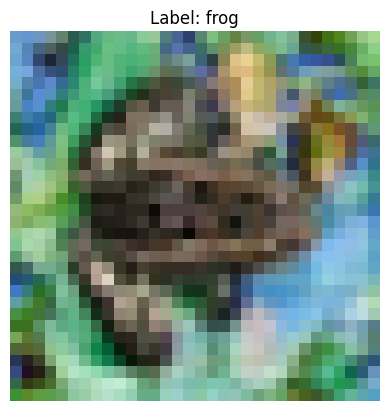

In [ ]:
n = 200
image, label = train_dataset.data[n], train_dataset.targets[n]

plt.imshow(image)
plt.title(f"Label: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()

- 랜덤 이미지 32장을 확인합니다.

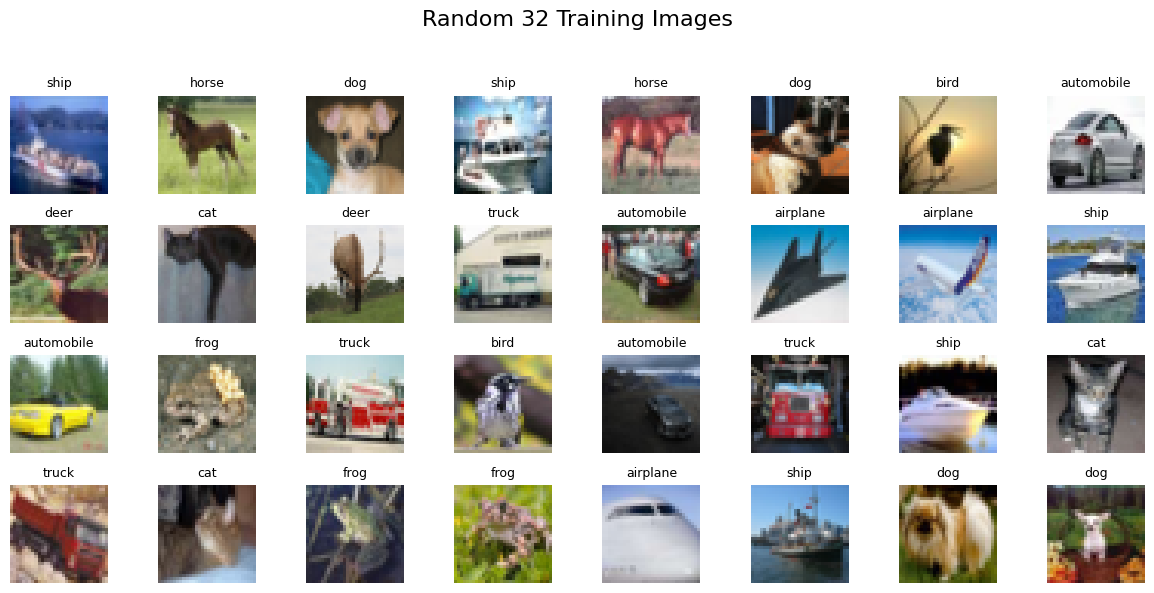

In [ ]:
num_images = 32
random_indices = torch.randint(0, len(train_dataset), (num_images,))

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle("Random 32 Training Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    index = random_indices[i].item()
    image, label = train_dataset.data[index], train_dataset.targets[index]

    ax.imshow(image)
    ax.set_title(f"{train_dataset.classes[label]}", fontsize=9)
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2. 데이터 준비

학습 데이터는 `DataLoader`로 만들고, validation/test 데이터는 텐서로 준비합니다.

### 2.1 Train DataLoader 생성

In [ ]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

- 첫 번째 배치의 shape을 확인합니다. CIFAR-10 이미지는 컬러 이미지이므로 채널 수가 3입니다.

In [ ]:
for x, y in train_dataloader:
    print(f"Shape of x [N, C, H, W]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


### 2.2 Validation/Test 데이터 준비

`test_dataset.data`에서 원본 이미지를 가져오면 `(N, H, W, C)` 구조입니다. 모델 입력에 맞게 `(N, C, H, W)`로 바꾼 뒤 스케일링과 ImageNet 정규화를 적용합니다.

In [ ]:
test_data = test_dataset.data
test_targets = np.array(test_dataset.targets)

In [ ]:
# 차원 위치 변경: (N, H, W, C) -> (N, C, H, W)
test_data = test_data.transpose((0, 3, 1, 2))

# 텐서 변환
test_data = torch.tensor(test_data, dtype=torch.float32)
test_targets = torch.tensor(test_targets, dtype=torch.long)

test_data.shape, test_targets.shape

(torch.Size([10000, 3, 32, 32]), torch.Size([10000]))

In [ ]:
x_val, x_test = test_data[:5000], test_data[5000:]
y_val, y_test = test_targets[:5000], test_targets[5000:]

x_val.shape, y_val.shape, x_test.shape, y_test.shape

(torch.Size([5000, 3, 32, 32]),
 torch.Size([5000]),
 torch.Size([5000, 3, 32, 32]),
 torch.Size([5000]))

- 스케일링과 정규화를 적용합니다.

In [ ]:
def normalize_with_imagenet_stats(x):
    x = x / 255.0
    mean = torch.tensor(imagenet_mean, dtype=torch.float32).view(1, 3, 1, 1)
    std = torch.tensor(imagenet_std, dtype=torch.float32).view(1, 3, 1, 1)
    return (x - mean) / std

x_val = normalize_with_imagenet_stats(x_val)
x_test = normalize_with_imagenet_stats(x_test)

## 3. 모델링

### 3.1 ResNet 구조 직접 확인

ResNet의 핵심은 입력을 몇 개의 layer 뒤 출력에 더하는 residual connection입니다. 이 구조는 깊은 신경망에서 기울기 소실 문제를 줄이는 데 도움이 됩니다.

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

### 3.2 전이학습 모델 선언

`torchvision`에서 ImageNet으로 사전 학습된 ResNet34 모델을 불러옵니다.

처음 실행할 때는 사전 학습 가중치 파일을 다운로드할 수 있습니다.

In [ ]:
model = resnet34(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 130MB/s]


### 3.3 분류층 교체

기존 ResNet34는 ImageNet의 1000개 클래스를 출력합니다. CIFAR-10은 10개 클래스이므로 마지막 `fc` layer의 출력 노드를 10개로 바꿉니다.

In [ ]:
n_class = len(classes)          # 10

# 특징을 보고 최종 정답을 고르는 층
model.fc = nn.Linear(
    in_features = model.fc.in_features,
    out_features = n_class,
    bias=True
)

model = model.to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 3.4 Loss와 Optimizer

`model.parameters()`를 옵티마이저에 전달하면 ResNet34 전체 파라미터를 CIFAR-10에 맞게 미세 조정합니다.

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.0001)

## 4. 학습

매 epoch마다 train loss, validation loss, validation accuracy를 기록합니다.

In [ ]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t + 1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

KeyboardInterrupt: 

### 4.1 학습 곡선

In [ ]:
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

## 5. 모델 평가

학습에 사용하지 않은 test 데이터로 최종 성능을 확인합니다.

In [ ]:
pred = evaluate_report(x_test, y_test, model, loss_fn, device, classes)